In [1]:
## -- Device-Agnostic for GPU --
import torch
print(f"ℹ️ Running on Cuda: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    get_ipython().run_line_magic('load_ext', 'cuml.accel')
    from cuml.preprocessing import TargetEncoder as cuTE
else:
    pass

ℹ️ Running on Cuda: False


In [2]:
import sys
import os
import gc

import joblib
import pickle

## -- DATA MANIPUALATION --
import numpy as np
import pandas as pd
import random

## -- VISUALISATION --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import shap
# import hvplot.pandas
# hvplot.extension('matplotlib')

## -- FUNCTIONAL TOOLS --
from google.colab import files
from itertools import combinations
from tqdm.notebook import tqdm
from time import time

# ## SCIKIT-LEARN
import sklearn
from sklearn.manifold import TSNE
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.metrics import mean_squared_error, PredictionErrorDisplay
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RepeatedKFold
from sklearn.feature_selection import mutual_info_regression, SequentialFeatureSelector as SFS1
from mlxtend.feature_selection import SequentialFeatureSelector as SFS2

# -- GBDTs --
import xgboost as xgb
import lightgbm as lgb
import catboost as cgb

import warnings

In [3]:
print(f"xgboost version: {xgb.__version__}")
print(f"lightgbm version: {lgb.__version__}")
print(f"catboost version: {cgb.__version__}")
print(f"sklearn version: {sklearn.__version__}")
print(f"shap version: {shap.__version__}")

xgboost version: 3.2.0
lightgbm version: 4.6.0
catboost version: 1.2.10
sklearn version: 1.6.1
shap version: 0.51.0


In [4]:
## -- Global Settings --
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', None)
plt.style.use("ggplot")
# sns.set_style("whitegrid")

## -- Set Global Seed --
SEED = 42
def set_global_seed(seed = SEED):
    np.random.seed(seed)
    random.seed(seed)

set_global_seed()

COLOR = '\033[32m'
RESET = '\033[0m'

# from google.colab import data_table
# data_table.enable_dataframe_formatter()

In [5]:
### Load Data ###
PATH = "/kaggle/input/playground-series-s5e10/"
submit = pd.read_csv(PATH+"sample_submission.csv")
train= pd.read_csv(PATH+"train.csv", index_col='id') #.drop('id', axis=1)
test = pd.read_csv(PATH+"test.csv", index_col='id') #.drop('id', axis=1)

ORIG_PATH = "/kaggle/input/simulated-roads-accident-data/"
orig = pd.concat([pd.read_csv(ORIG_PATH+"synthetic_road_accidents_100k.csv"),
                  pd.read_csv(ORIG_PATH+"synthetic_road_accidents_10k.csv"),
                  pd.read_csv(ORIG_PATH+"synthetic_road_accidents_2k.csv")],
        ignore_index=True)

TARGET = "accident_risk"
NUMS = test.select_dtypes(include='number').columns.tolist()
CATS = test.select_dtypes(exclude='number').columns.tolist()
FEATURES = NUMS + CATS

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(FEATURES)}")

Train shape: (517754, 13)
Test shape: (172585, 12)
Original shape: (112000, 13)

Total Numerical: 4
Total Categorical: 8
Total base features: 12


In [6]:
# print(f"Train ID column is Unique: {train.id.is_unique}")
# print(f"Test ID column is Unique: {test.id.is_unique}")

In [7]:
display(train.head())
train.info()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


<class 'pandas.core.frame.DataFrame'>
Index: 517754 entries, 0 to 517753
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               517754 non-null  object 
 1   num_lanes               517754 non-null  int64  
 2   curvature               517754 non-null  float64
 3   speed_limit             517754 non-null  int64  
 4   lighting                517754 non-null  object 
 5   weather                 517754 non-null  object 
 6   road_signs_present      517754 non-null  bool   
 7   public_road             517754 non-null  bool   
 8   time_of_day             517754 non-null  object 
 9   holiday                 517754 non-null  bool   
 10  school_season           517754 non-null  bool   
 11  num_reported_accidents  517754 non-null  int64  
 12  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(2), int64(3), object(4)
memory usage: 41.5+ MB


In [8]:
display(test.head())
test.info()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
id,,,,,,,,,,,,
517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1
517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0
517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1
517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2
517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3


<class 'pandas.core.frame.DataFrame'>
Index: 172585 entries, 517754 to 690338
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               172585 non-null  object 
 1   num_lanes               172585 non-null  int64  
 2   curvature               172585 non-null  float64
 3   speed_limit             172585 non-null  int64  
 4   lighting                172585 non-null  object 
 5   weather                 172585 non-null  object 
 6   road_signs_present      172585 non-null  bool   
 7   public_road             172585 non-null  bool   
 8   time_of_day             172585 non-null  object 
 9   holiday                 172585 non-null  bool   
 10  school_season           172585 non-null  bool   
 11  num_reported_accidents  172585 non-null  int64  
dtypes: bool(4), float64(1), int64(3), object(4)
memory usage: 12.5+ MB


In [9]:
display(orig.head())
orig.info()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,rural,2,0.29,70,night,rainy,False,True,evening,False,False,1,0.64
1,highway,1,0.34,25,dim,clear,False,False,morning,False,False,3,0.27
2,rural,2,0.76,70,night,foggy,True,False,evening,True,True,1,0.76
3,rural,3,0.37,70,night,foggy,True,False,morning,False,True,0,0.60
4,highway,3,0.39,45,dim,rainy,False,True,morning,False,False,0,0.17


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112000 entries, 0 to 111999
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               112000 non-null  object 
 1   num_lanes               112000 non-null  int64  
 2   curvature               112000 non-null  float64
 3   speed_limit             112000 non-null  int64  
 4   lighting                112000 non-null  object 
 5   weather                 112000 non-null  object 
 6   road_signs_present      112000 non-null  bool   
 7   public_road             112000 non-null  bool   
 8   time_of_day             112000 non-null  object 
 9   holiday                 112000 non-null  bool   
 10  school_season           112000 non-null  bool   
 11  num_reported_accidents  112000 non-null  int64  
 12  accident_risk           112000 non-null  float64
dtypes: bool(4), float64(2), int64(3), object(4)
memory usage: 8.1+ MB


In [10]:
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
road_type,517754,3,highway,173672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_lanes,517754.0,NaN,NaN,NaN,2.491511,1.120434,1.0,1.0,2.0,3.0,4.0
curvature,517754.0,NaN,NaN,NaN,0.488719,0.272563,0.0,0.26,0.51,0.71,1.0
speed_limit,517754.0,NaN,NaN,NaN,46.112575,15.788521,25.0,35.0,45.0,60.0,70.0
lighting,517754,3,dim,183826,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather,517754,3,foggy,181463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
road_signs_present,517754,2,False,259289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
public_road,517754,2,True,260045,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_of_day,517754,3,morning,173410,NaN,NaN,NaN,NaN,NaN,NaN,NaN
holiday,517754,2,True,260688,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Check if column names are the same regardless of order
are_same_set = set(train.columns) == set(orig.columns)
print(f"Are column names the same regardless of order (train vs orig)? {are_same_set}")

# Check if column names are exactly the same and in the same order
are_same_exact = train.columns.equals(orig.columns)
print(f"Are column names exactly the same and in the same order (train vs orig)? {are_same_exact}")

Are column names the same regardless of order (train vs orig)? True
Are column names exactly the same and in the same order (train vs orig)? True


In [12]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in FEATURES:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,num_lanes,curvature,speed_limit,num_reported_accidents,road_type,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season
Train,4,261,5,8,3,3,3,2,2,3,2,2
Original,4,101,5,11,3,3,3,2,2,3,2,2
Test,4,195,5,8,3,3,3,2,2,3,2,2


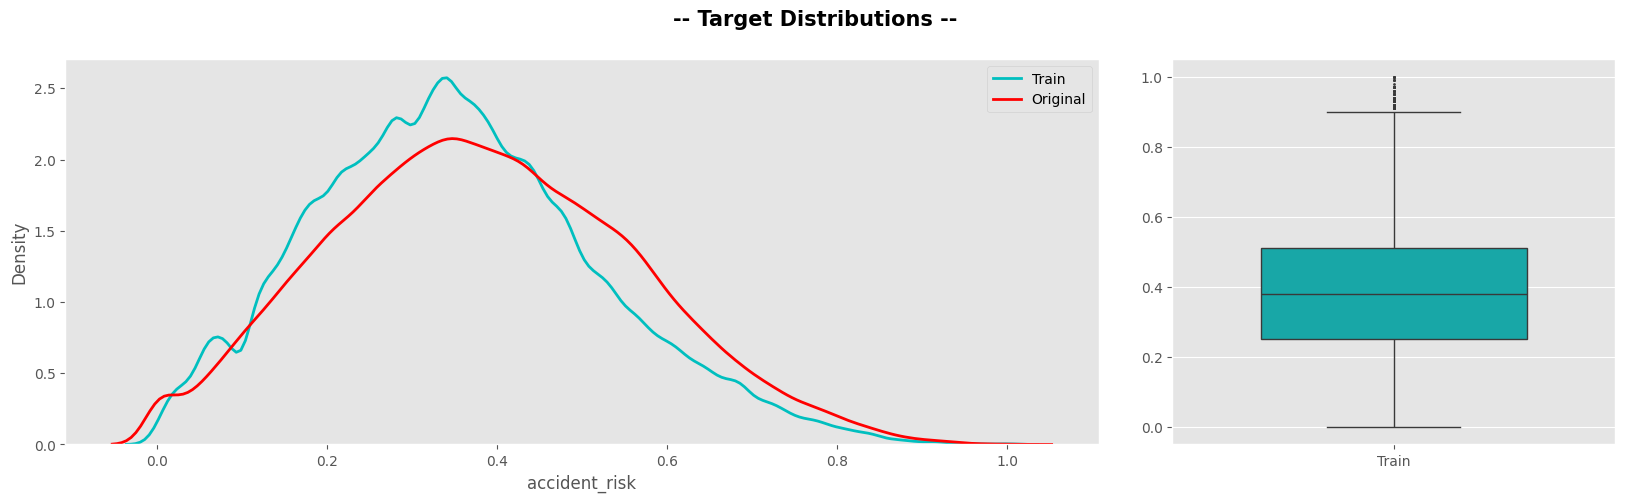

In [13]:
# Target distribution (Train vs Original)
PALETTE = ['c', 'r']
_, axs2 = plt.subplots(1, 2, figsize=(20, 5),
                         gridspec_kw=dict(width_ratios=[0.7, 0.3], wspace=0.1)
                        )
# KDEs
sns.kdeplot(data=train, x=TARGET, color=PALETTE[0], ax=axs2[0], linewidth=2, label='Train')
sns.kdeplot(data=orig,  x=TARGET, color=PALETTE[1], ax=axs2[0], linewidth=2, label='Original')
axs2[0].legend()
axs2[0].grid()
# BoxplotS
sns.boxplot(data=[train[TARGET], orig[TARGET]], width=0.6,
            linewidth=1, fliersize=1, ax=axs2[1], palette=PALETTE)
axs2[1].set_xticklabels(['Train', 'Original'])
plt.suptitle("-- Target Distributions --", fontsize=15, fontweight='semibold')
plt.tight_layout()
plt.show()

In [14]:
# hvplot.help('line')

In [15]:
# distplot = (
#     train.hvplot.kde(y=TARGET, label='Train', width=800, height=350) * \
#     orig.hvplot.kde(y=TARGET, label='Original')
# ).opts(active_tools=["pan"], title="Distribution of Target")

# boxplot  = (
#     train.hvplot.box(y=TARGET, label='Train', width=400, height=350) * \
#     orig.hvplot.box(y=TARGET, bgcolor='lightgray', label='Original')
# ).opts(active_tools=["pan"], title="Boxplot of Target")

# display(distplot + boxplot)

In [16]:
# def distplots_data(
#                     train: pd.DataFrame,
#                     test: pd.DataFrame,
#                     orig: pd.DataFrame,
#                     features: list[str]):

#     # 1) Concatenate data
#     df = pd.concat([
#             train[features].assign(Source='Train'),
#             test[features].assign(Source='Test'),
#             orig[features].assign(Source='Original')
#     ], ignore_index=True)
    
#     PALETTE = ['c', 'r', 'orange']

#     # 2) Create a grid: one row per feature, two columns (KDE vs Boxplot)
#     n_features = len(features)
#     fig, axs = plt.subplots(
#             n_features, 2, figsize=(20, max(5, n_features * 4)),
#             gridspec_kw={'hspace': 0.3, 'wspace': 0.15, 'width_ratios': [0.7, 0.3]})
    
#     # Ensure axs is always 2D for consistent indexing
#     if n_features == 1:
#         axs = axs.reshape(1, 2)
    
#     for i, col in enumerate(features):
#         ax_kde = axs[i, 0]
#         sns.kdeplot(data=df[[col, 'Source']], x=col, hue='Source',
#                     palette=PALETTE, ax=ax_kde, linewidth=2)
#         ax_kde.set(xlabel='', ylabel='')
#         ax_kde.set_title(f"\n{col}")
#         ax_kde.grid()
    
#         ax_box = axs[i, 1]
#         sns.boxplot(data=df, y=col, x='Source', width=0.5, linewidth=1,
#                     fliersize=1, ax=ax_box, palette=PALETTE)
#         ax_box.set_title(f"\n{col}")
#         ax_box.set(xlabel='', ylabel='')
#         ax_box.tick_params(axis='both', which='major')
#         ax_box.set_xticklabels(['Train', 'Test', 'Original'])
    
#     plt.tight_layout()
#     plt.show()

In [17]:
# def distplots_data(
#                     train: pd.DataFrame,
#                     test: pd.DataFrame,
#                     orig: pd.DataFrame,
#                     features: list[str]):
    
#     for i, col in enumerate(features):
#         LABELS = ['Train', 'Test', 'Original']
#         distplot = ( 
#             train.hvplot.kde(y=col, label=LABELS[0], width=650, height=350) * \
#             test.hvplot.kde(y=col, label=LABELS[1]) * \
#             orig.hvplot.kde(y=col, label=LABELS[2])
#         ).opts(active_tools=["pan"], title=f"{col} distribution")
        
#         boxplot  = (
#             train.hvplot.box(y=col, label=LABELS[0], width=350, height=350) * \
#             test.hvplot.box(y=col, label=LABELS[1]) * \
#             orig.hvplot.box(y=col, label=LABELS[2], bgcolor='lightgray')
#         ).opts(active_tools=["pan"], title=f"Boxplot of {col}")
        
#         display(distplot + boxplot)

In [18]:
# distplots_data(train, test, orig, NUMS) # Use for floats

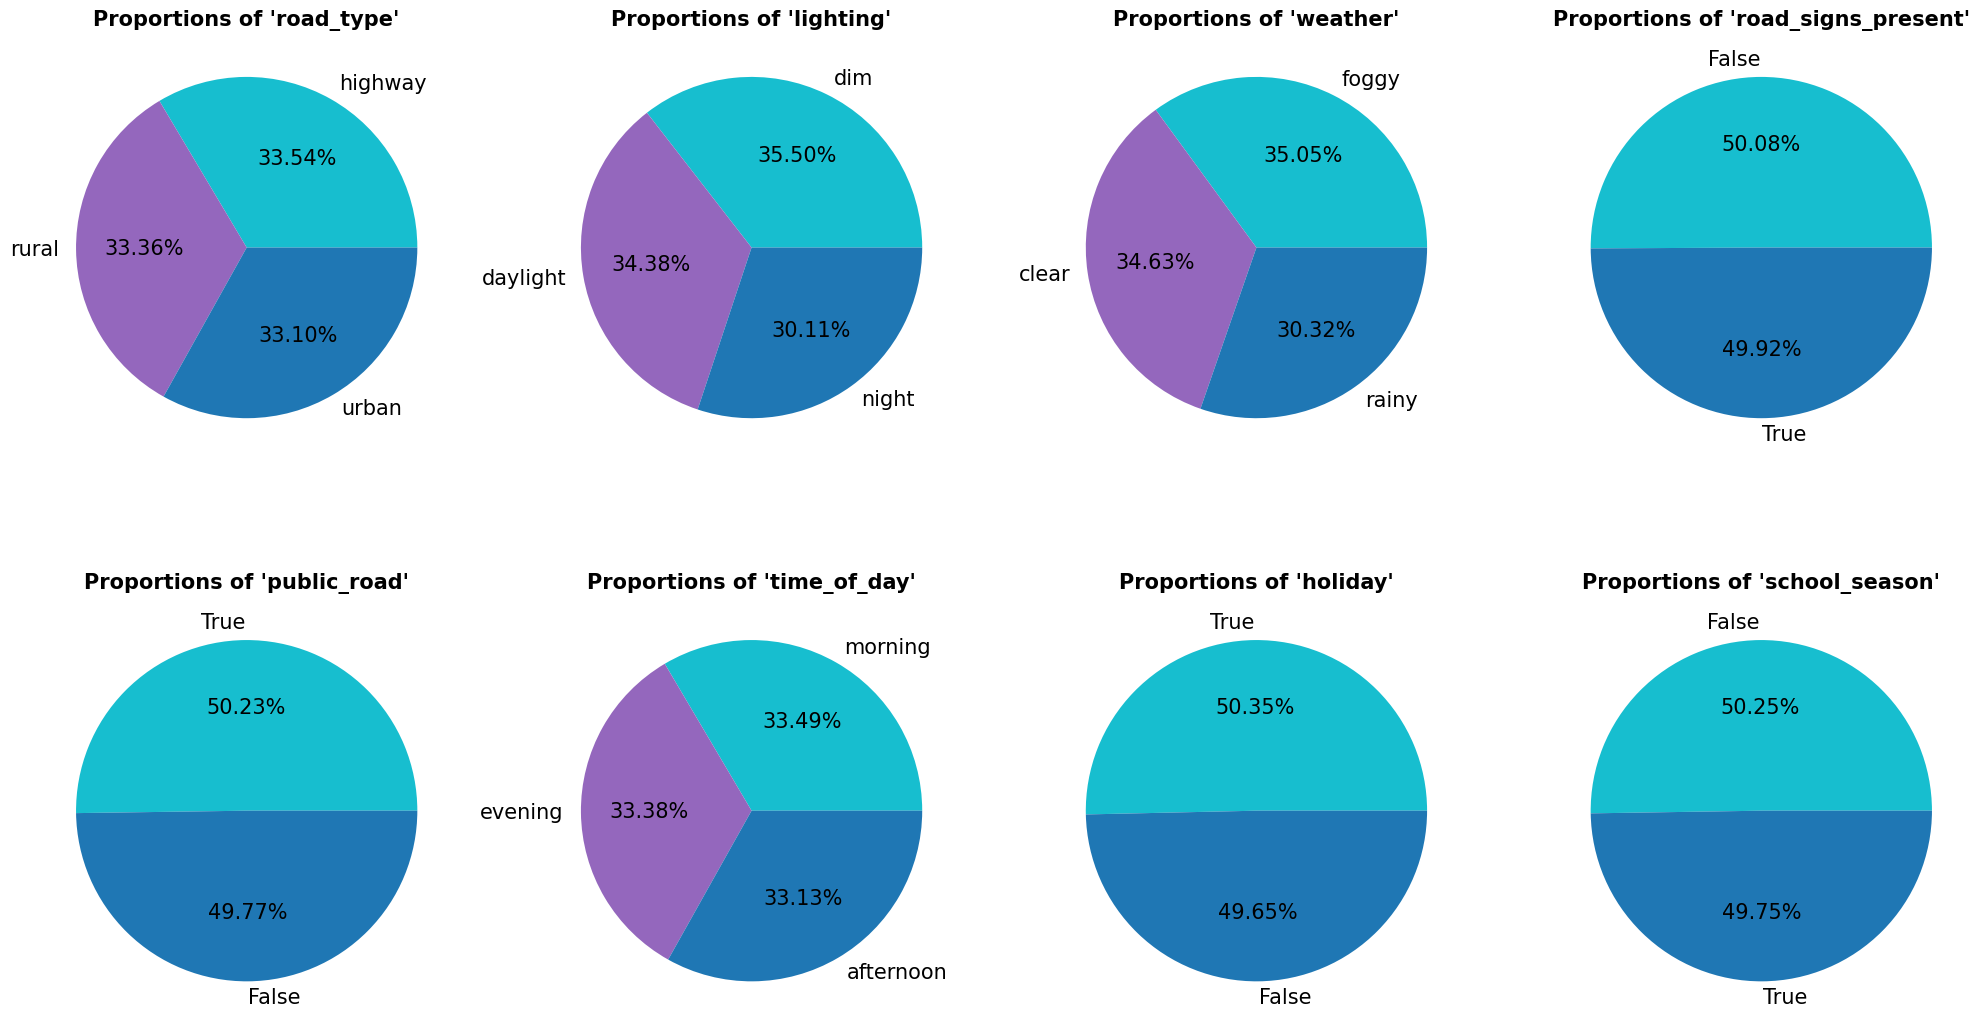

In [19]:
## -- Categorical Features --
plt.figure(figsize=(20, 12))
for i, col in enumerate(CATS):
    plt.subplot(2, 4, i+1)
    values=train[col].value_counts(dropna=False)
    values.plot(kind='pie', autopct='%1.2f%%', fontsize=15, cmap='tab10_r')
    plt.title(f"Proportions of '{col}'", fontsize=15, fontweight='semibold')
    plt.axis('off')

plt.tight_layout()
plt.show()

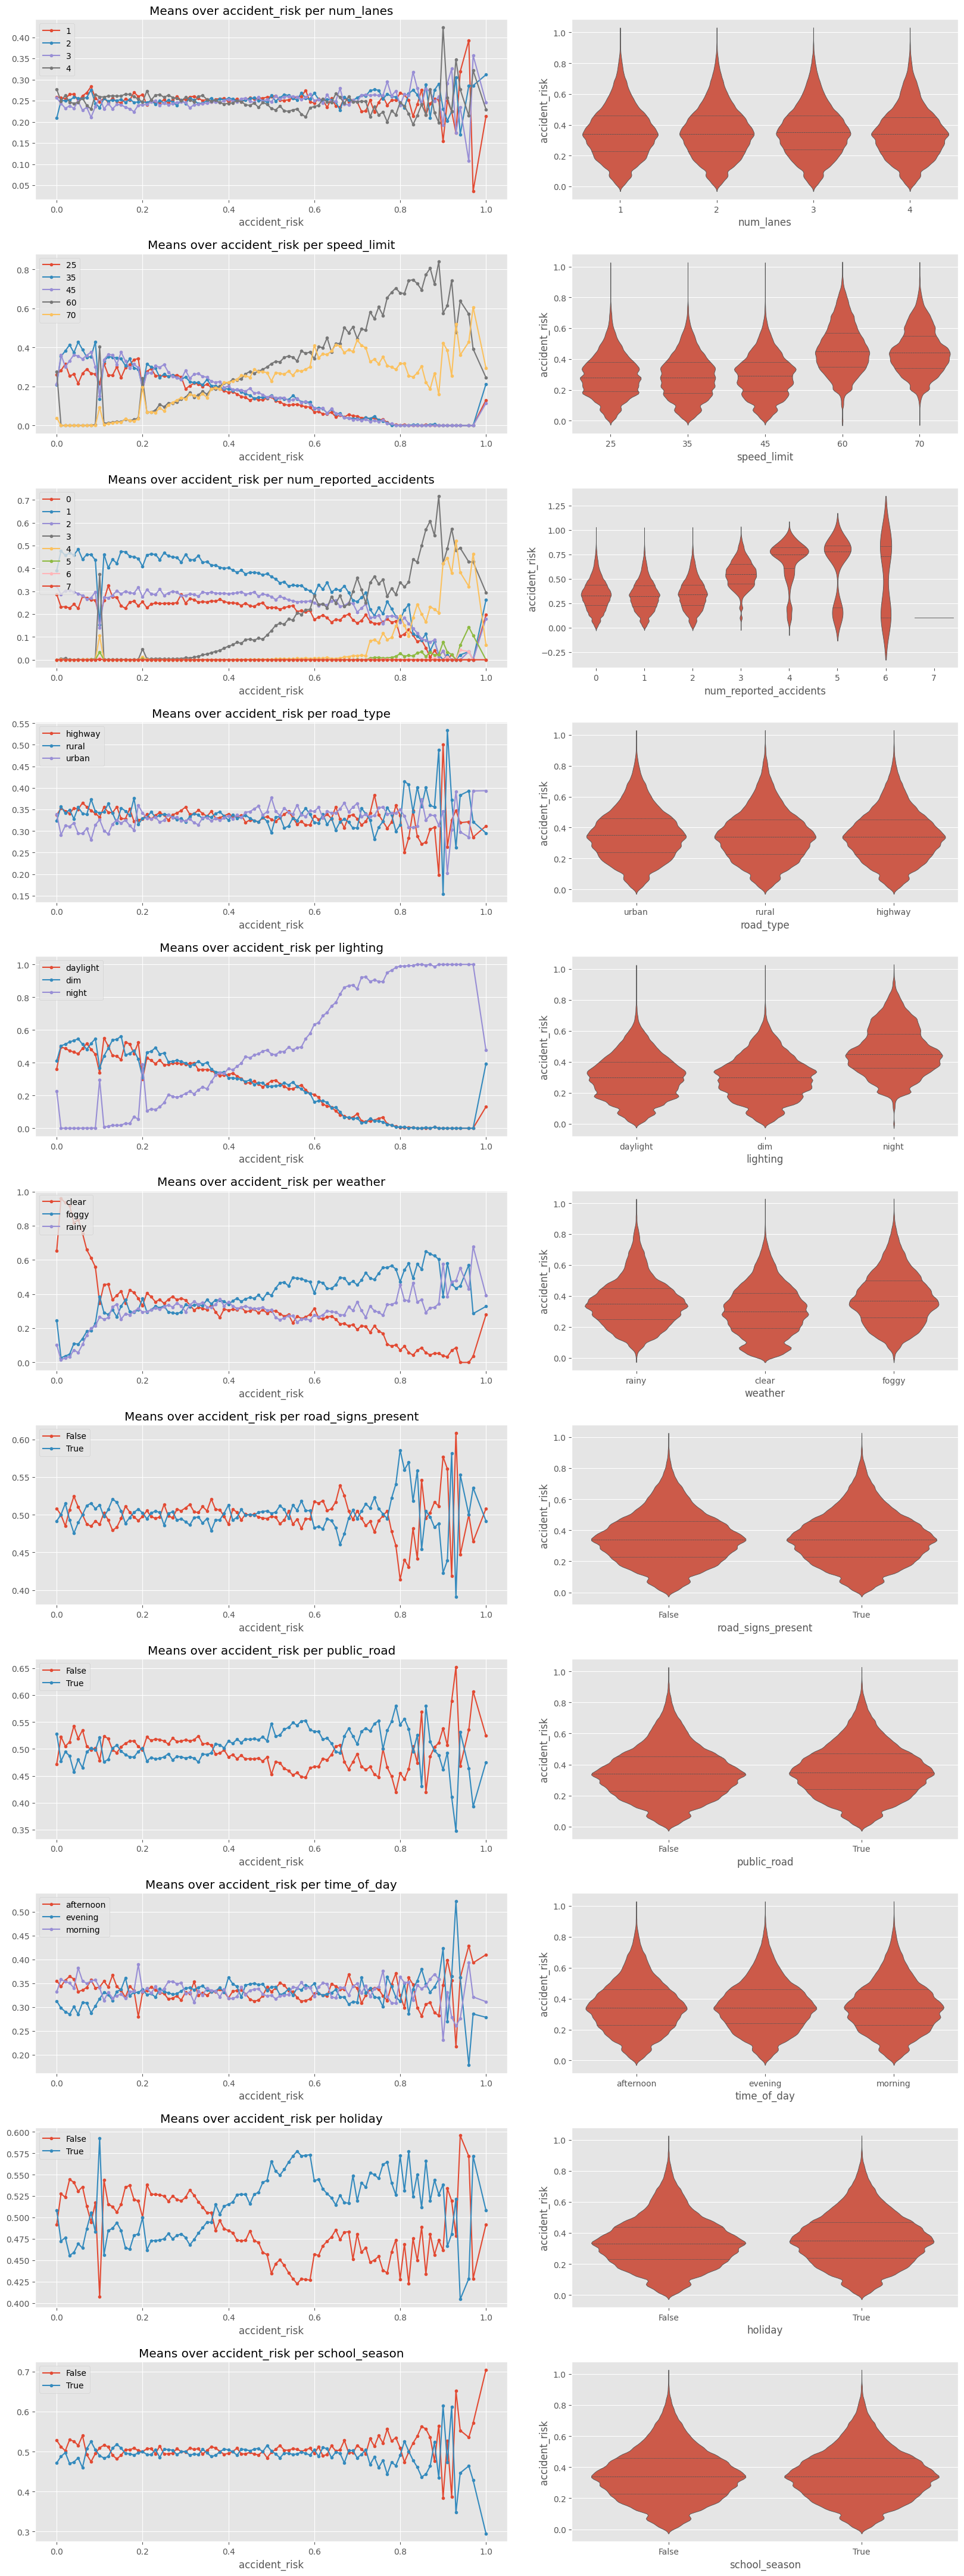

In [20]:
## -- Value counts of category by target --
FEAT = FEATURES.copy()
FEAT.remove('curvature')
N_FEAT = len(FEAT)

## -- Create a grid: one row per feature, two columns (KDE vs Boxplot)
fig, axs = plt.subplots(
        N_FEAT, 2, figsize=(20, max(5, N_FEAT * 5)),
        gridspec_kw=dict(hspace=0.3, wspace=0.15, width_ratios=[0.55, 0.45])
    )
## -- Ensure axs is always 2D for consistent indexing
if N_FEAT == 1:
    axs = axs.reshape(1, 2)

for i, col in enumerate(FEAT):
    tmp = (
            train.groupby(TARGET)[col]
            .value_counts(normalize=True)
            .unstack()
            .fillna(0)
        )
    ax1 = axs[i, 0] # Plot 1
    # sns.lineplot(tmp, ax=ax1, markers=True)
    tmp.plot(ax=ax1, marker='.', title=f'Means over {TARGET} per {col}')
    ax1.legend(loc='upper left')

    ax2 = axs[i, 1] # Plot 2
    sns.violinplot(train, x=col, y=TARGET, ax=ax2, inner='quart')
    # ax2.tick_params(axis='both', which='major')

plt.tight_layout()
plt.show()

In [21]:
## -- Label encoding --
df = pd.concat([train, test, orig], ignore_index=True)

for c in CATS:
    df[c] = df[c].factorize()[0]
    # df[c] = df[c].astype('int8')

train = df.iloc[:len(train)].reset_index(drop=True)
test  = df.iloc[len(train):len(train)+len(test)].drop(TARGET, axis=1).reset_index(drop=True)
orig  = df.iloc[len(train)+len(test):].reset_index(drop=True)

train.shape, test.shape, orig.shape

((517754, 13), (172585, 12), (112000, 13))

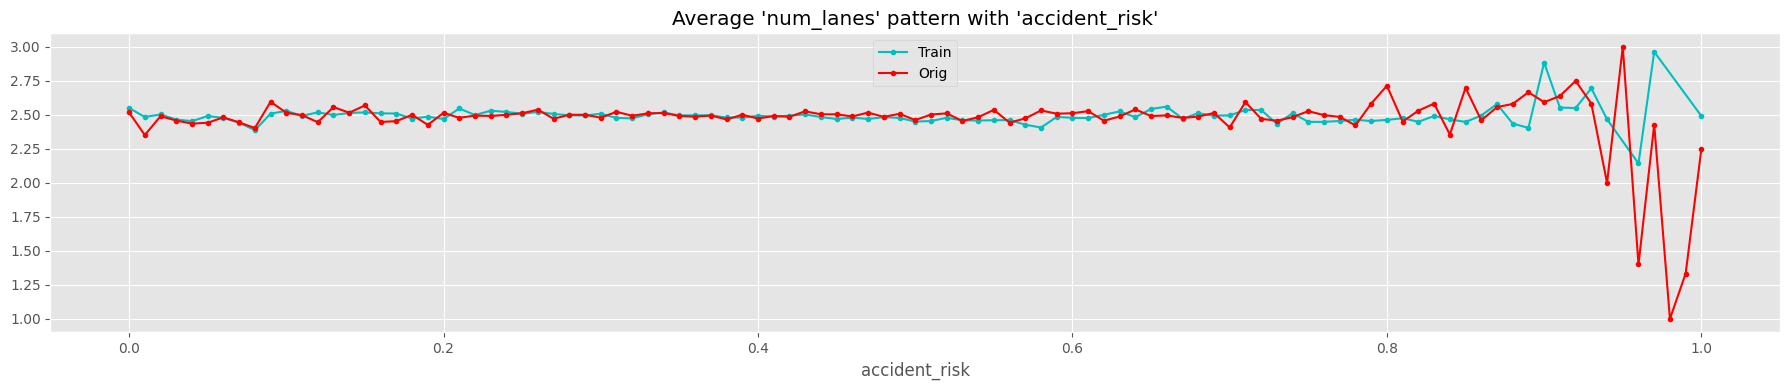

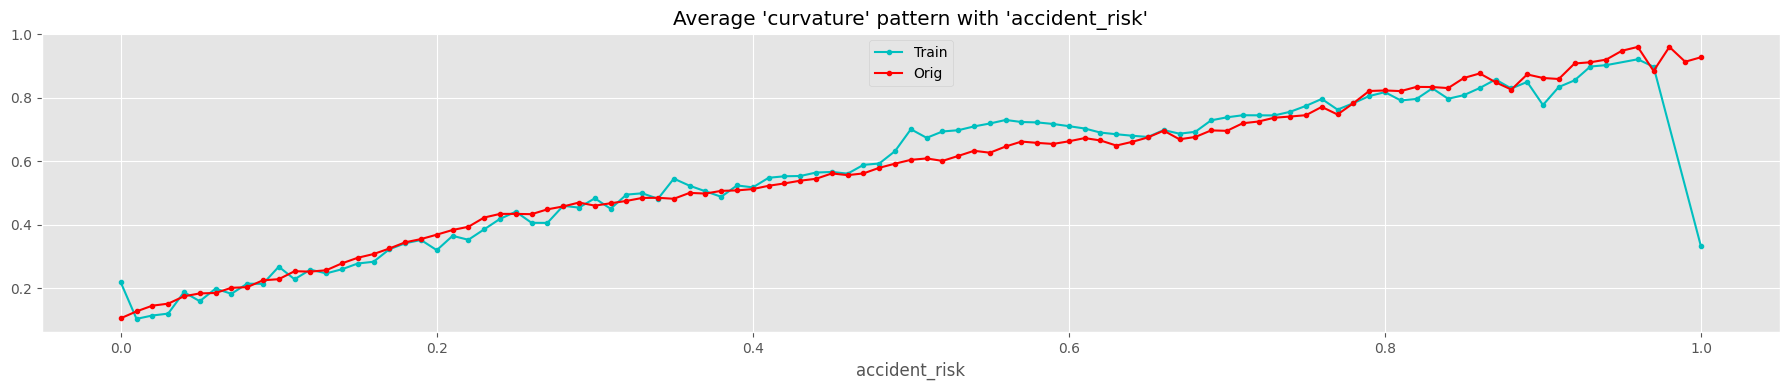

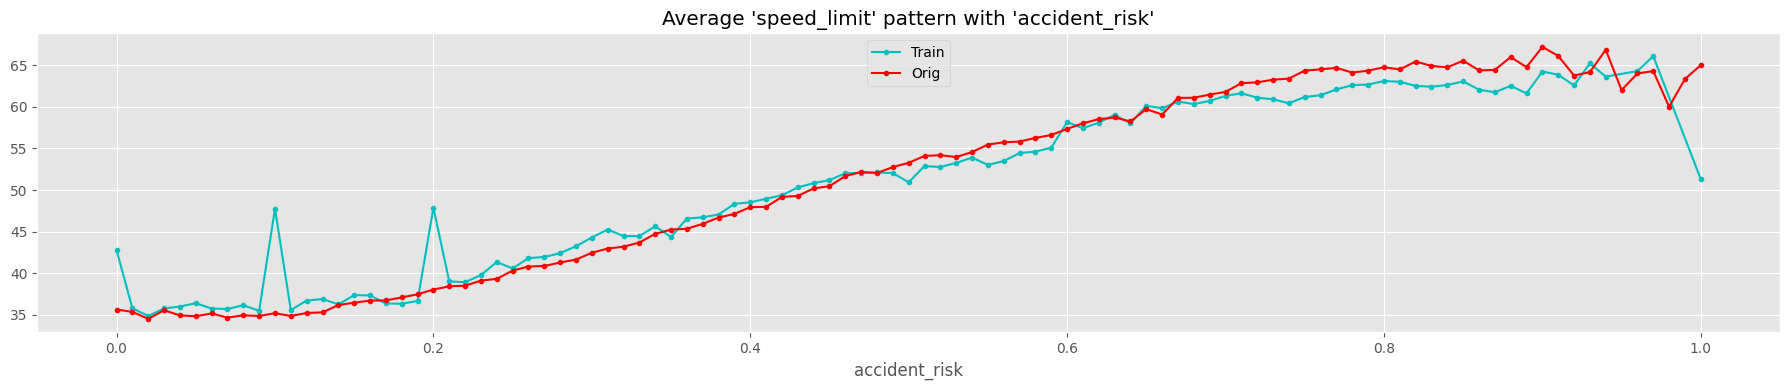

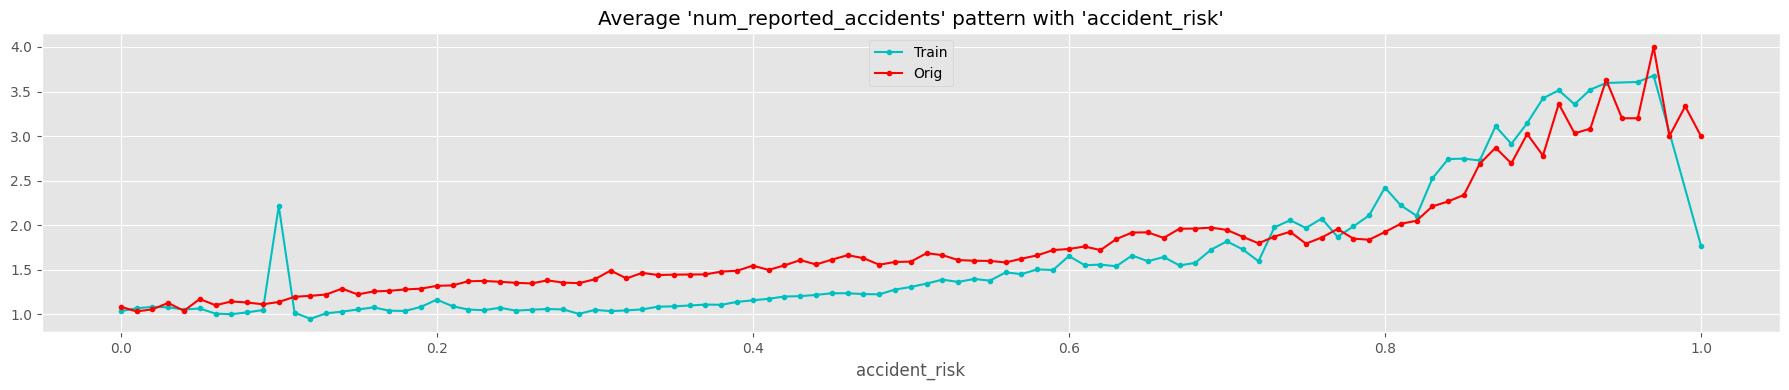

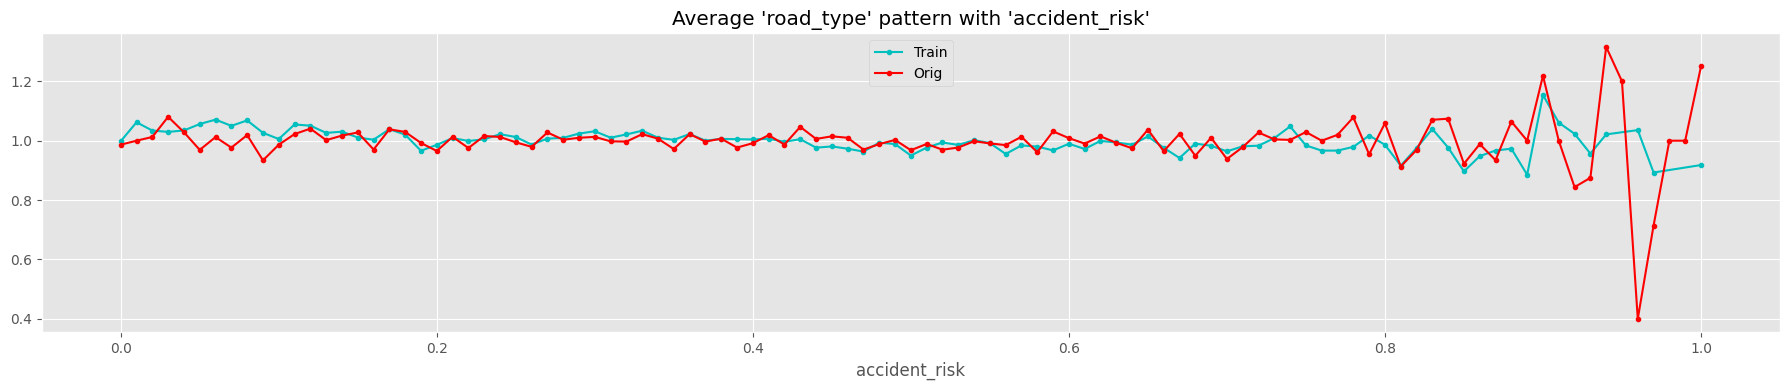

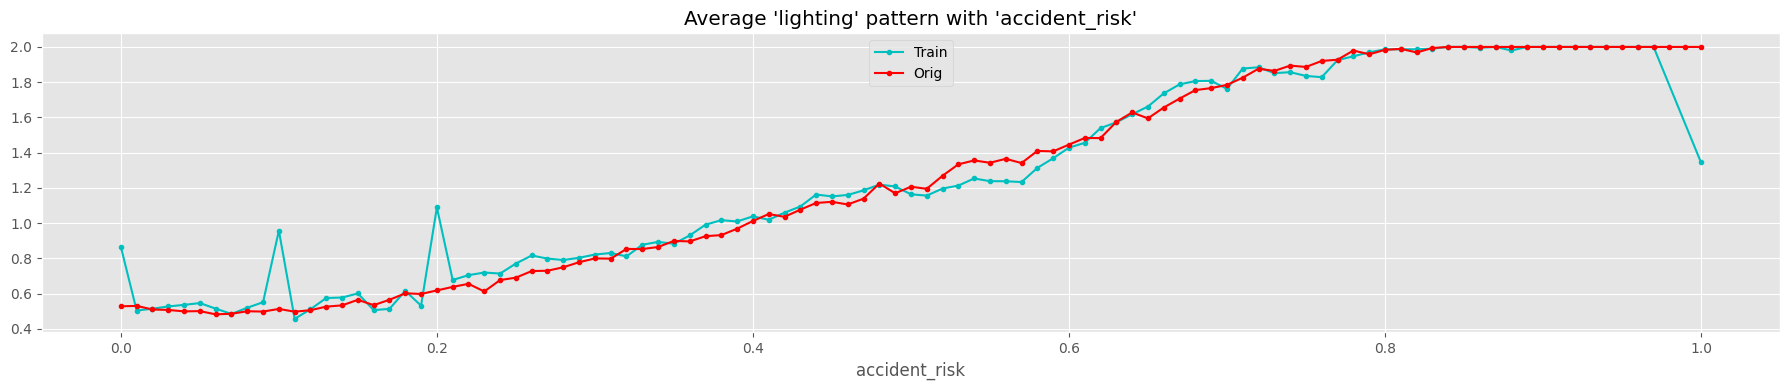

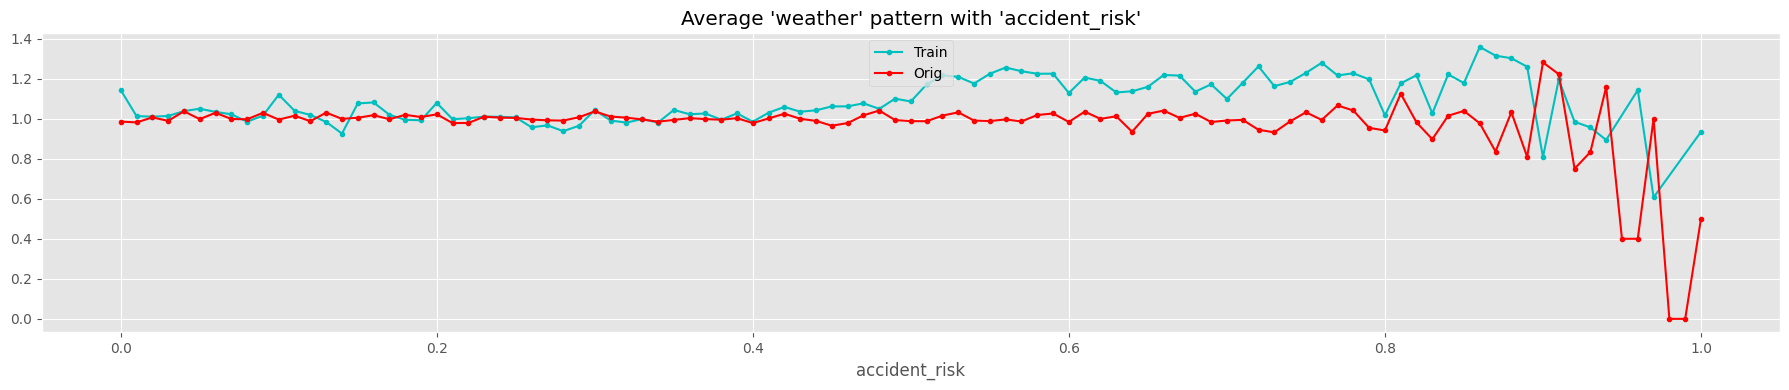

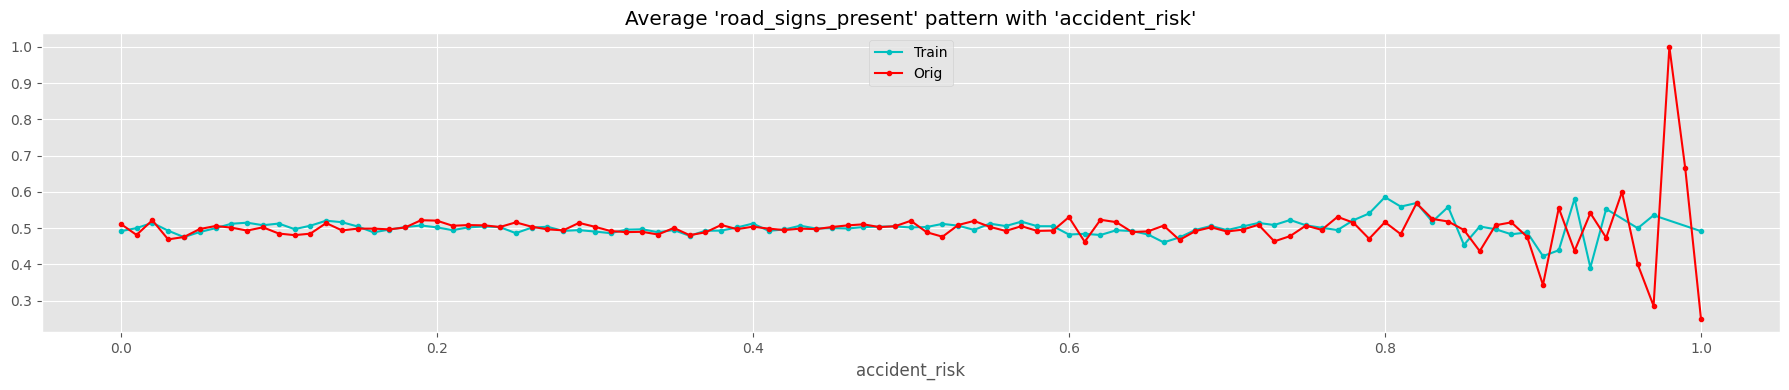

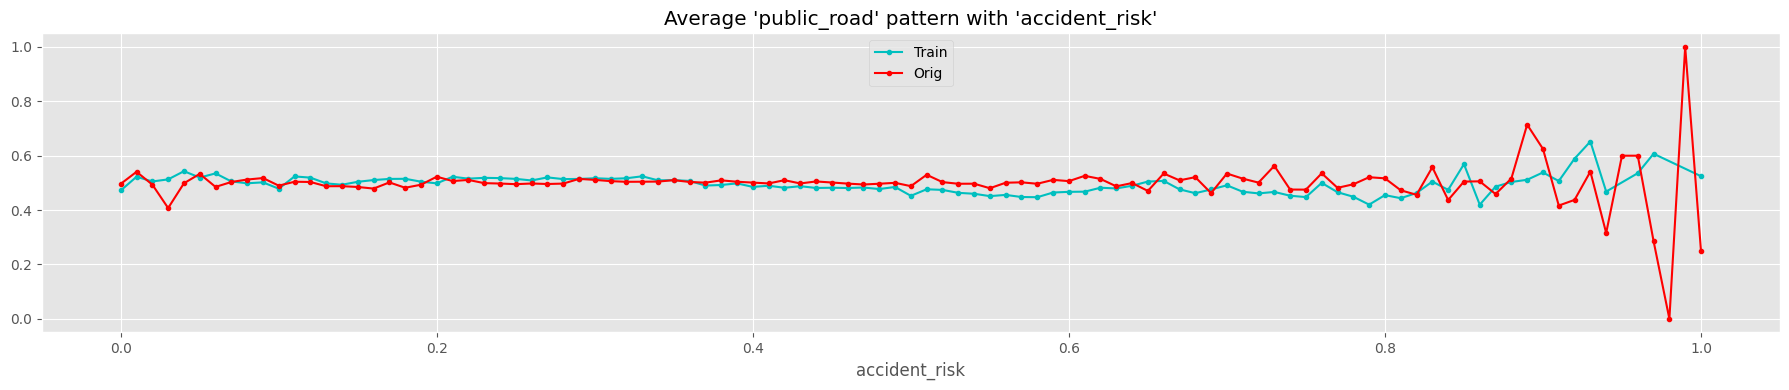

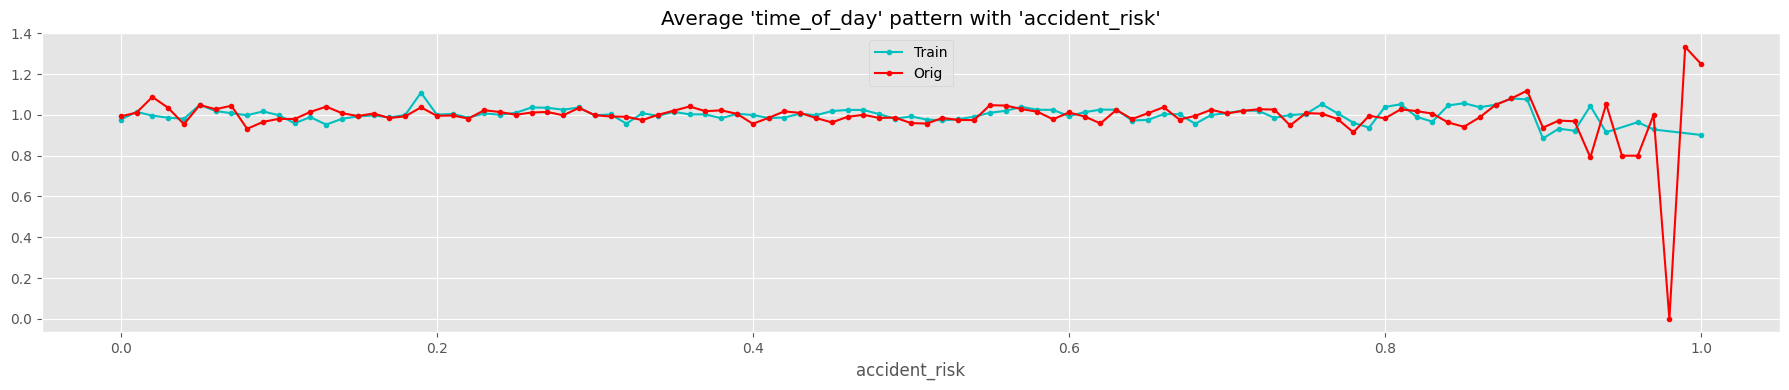

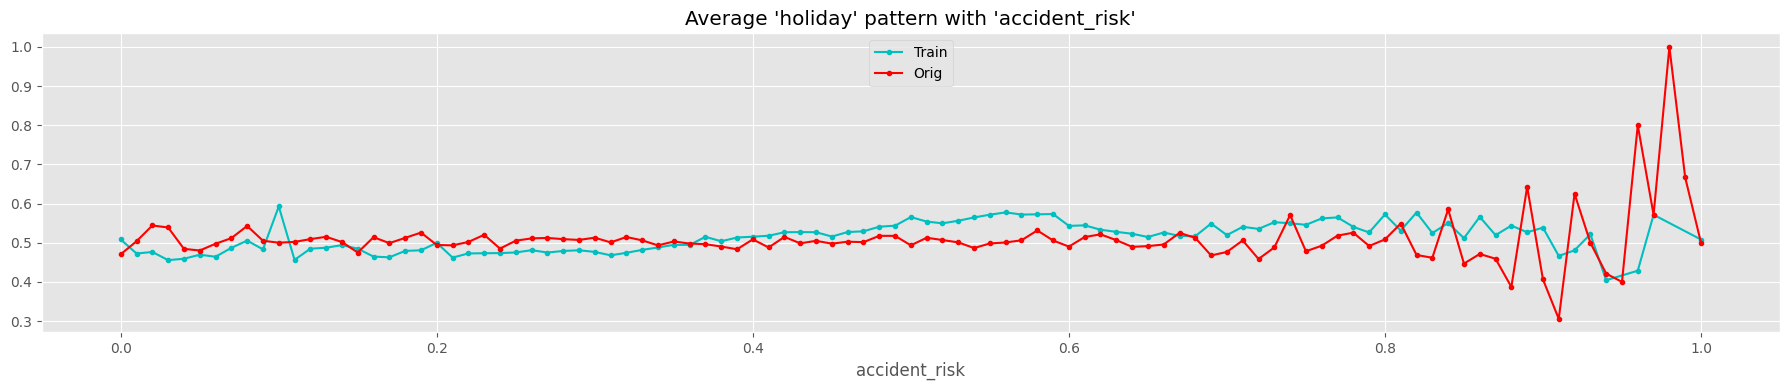

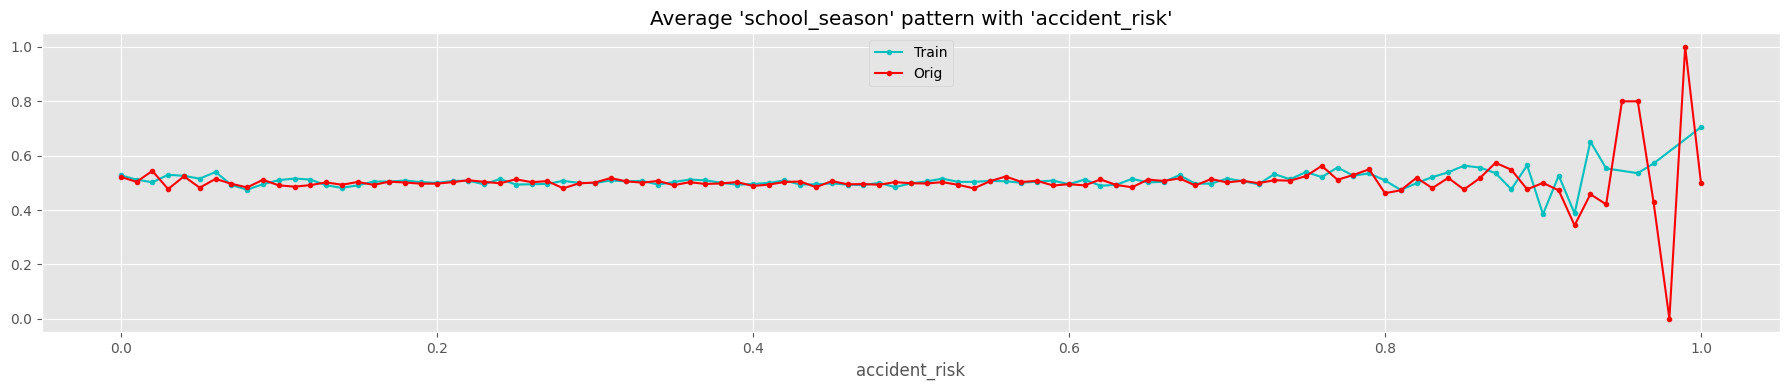

In [22]:
## -- Train/Test relationship: Average risks by category --
for i, col in enumerate(FEATURES):
    plt.figure(figsize=(18, 4))
    df = (train.groupby(TARGET)[col].mean())
    df1 = (orig.groupby(TARGET)[col].mean())
    ax = df.plot(marker='.', color='c', label='Train')
    df1.plot(ax=ax, marker='.', color='r', label='Orig')
    ax.set_title(f"Average '{col}' pattern with '{TARGET}'")
    ax.legend(loc='upper center')
    plt.tight_layout()
    
plt.show()

In [23]:
def plot_heatmap(data):
    df = data.copy()
    CORR = df.corr('spearman')
    plt.figure(figsize=(18, 7))
    sns.heatmap(CORR, mask=np.triu(CORR), annot=True, cbar=False)
    plt.tight_layout()
    plt.show()
    
    del df

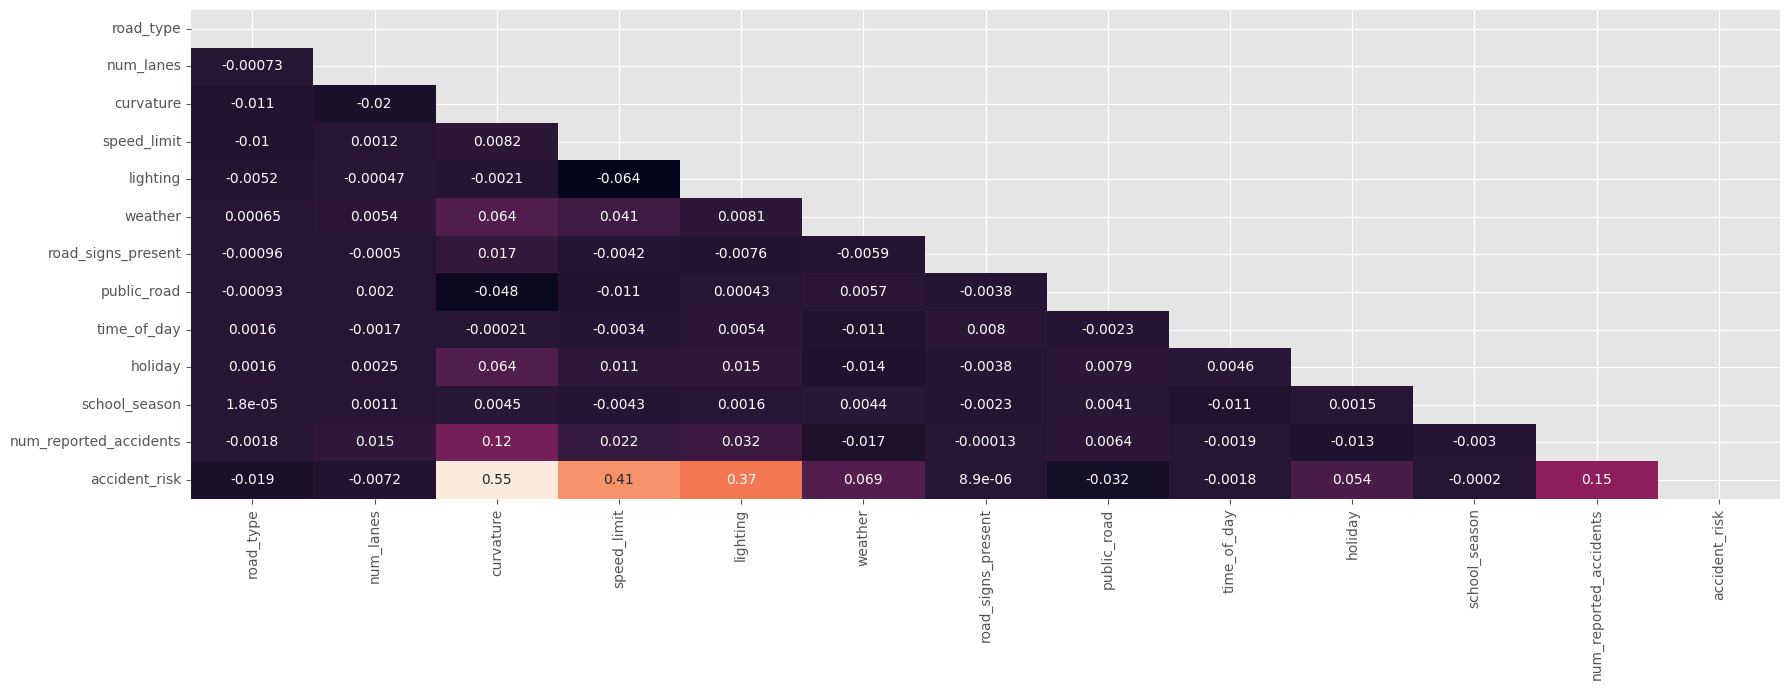

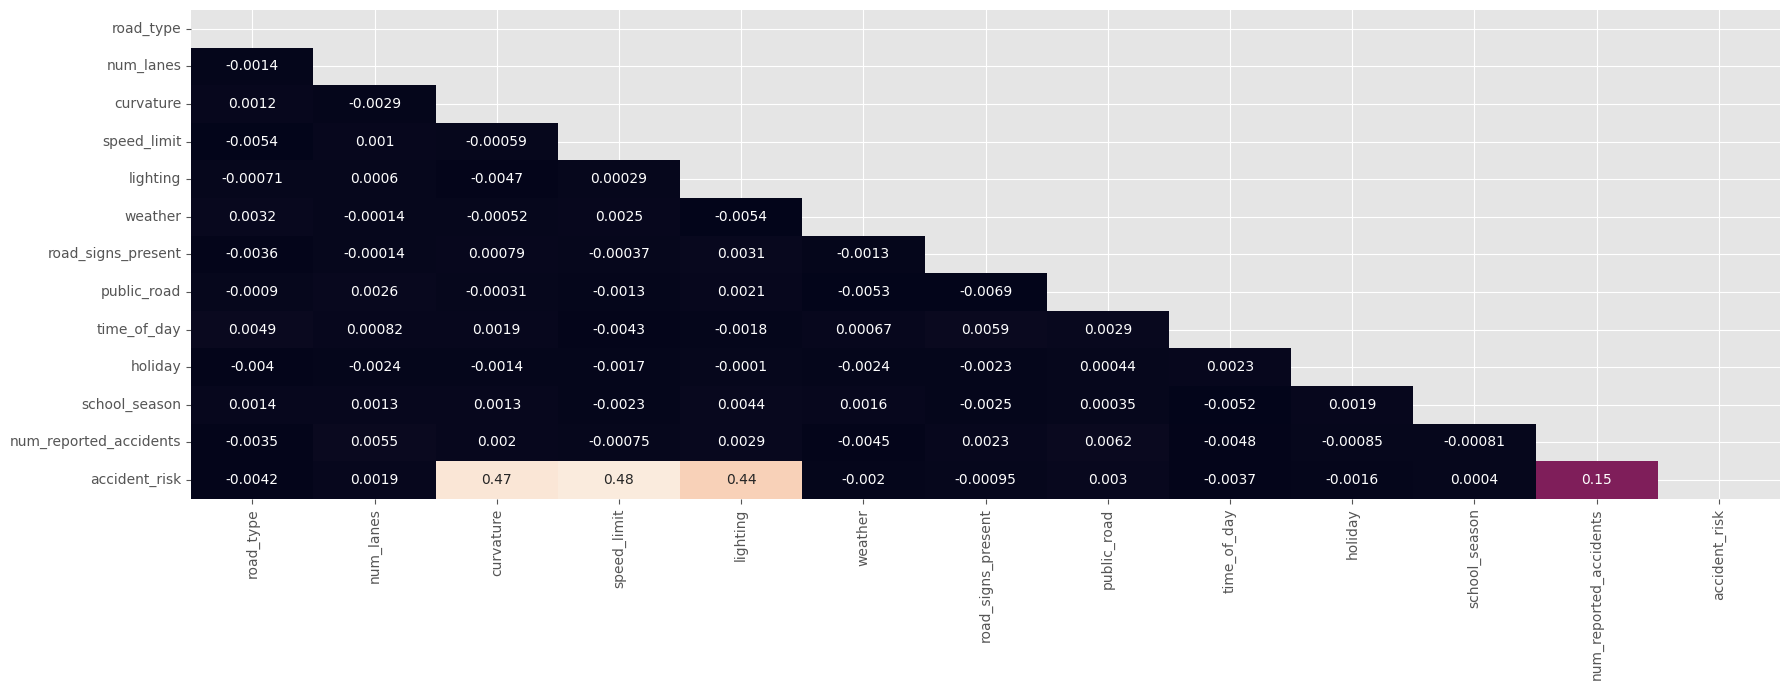

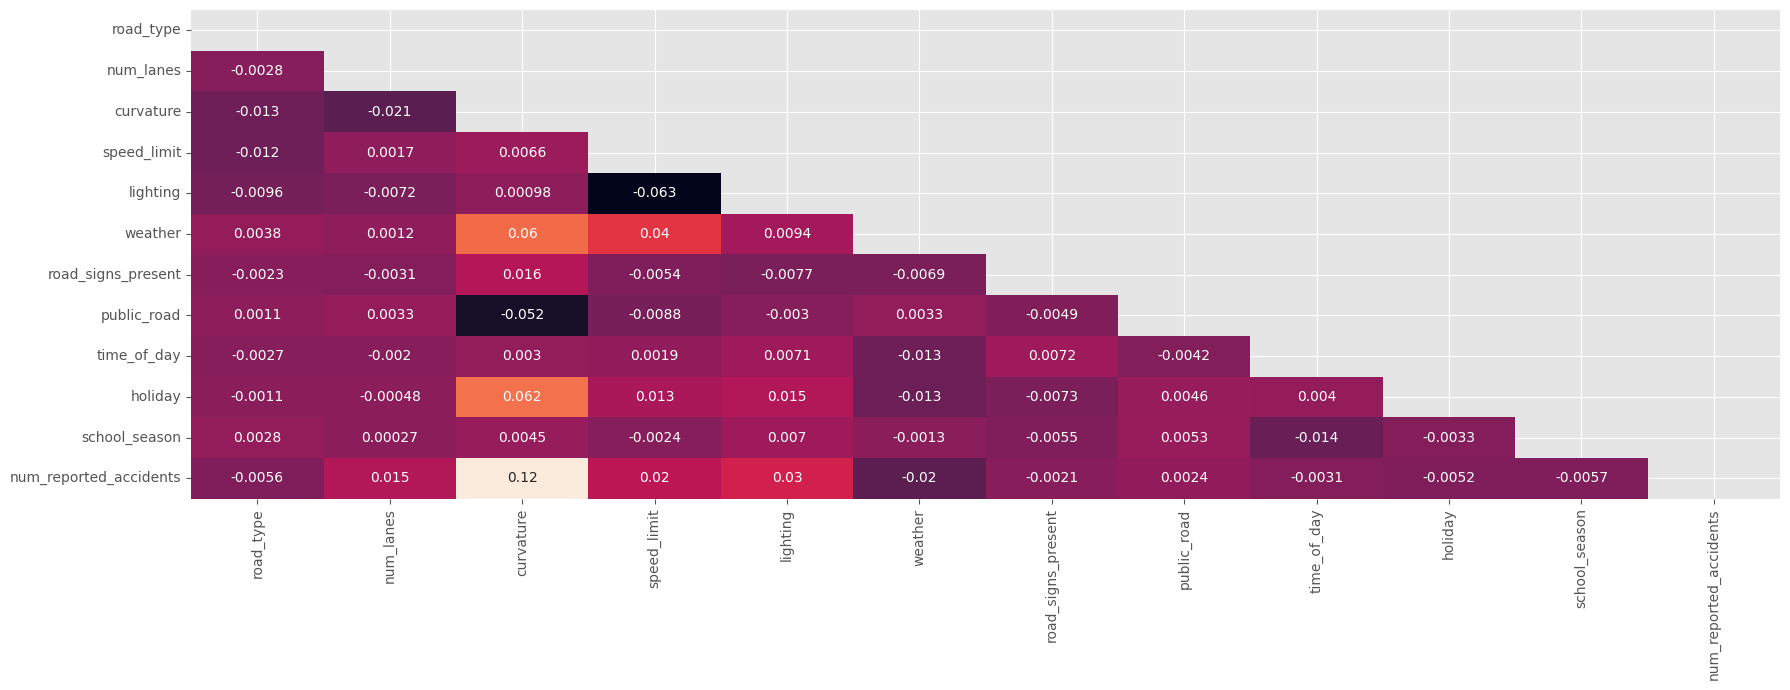

(None, None, None)

In [24]:
plot_heatmap(train), plot_heatmap(orig), plot_heatmap(test)

In [25]:
display(train.head())
train.info()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,2,0.06,35,0,0,0,0,0,0,0,1,0.13
1,0,4,0.99,35,0,1,1,1,1,1,0,0,0.35
2,1,4,0.63,70,1,1,0,0,2,1,1,2,0.30
3,2,4,0.07,35,1,0,1,0,2,0,1,1,0.21
4,1,1,0.58,60,0,2,0,1,1,1,1,1,0.56


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               517754 non-null  int64  
 1   num_lanes               517754 non-null  int64  
 2   curvature               517754 non-null  float64
 3   speed_limit             517754 non-null  int64  
 4   lighting                517754 non-null  int64  
 5   weather                 517754 non-null  int64  
 6   road_signs_present      517754 non-null  int64  
 7   public_road             517754 non-null  int64  
 8   time_of_day             517754 non-null  int64  
 9   holiday                 517754 non-null  int64  
 10  school_season           517754 non-null  int64  
 11  num_reported_accidents  517754 non-null  int64  
 12  accident_risk           517754 non-null  float64
dtypes: float64(2), int64(11)
memory usage: 51.4 MB


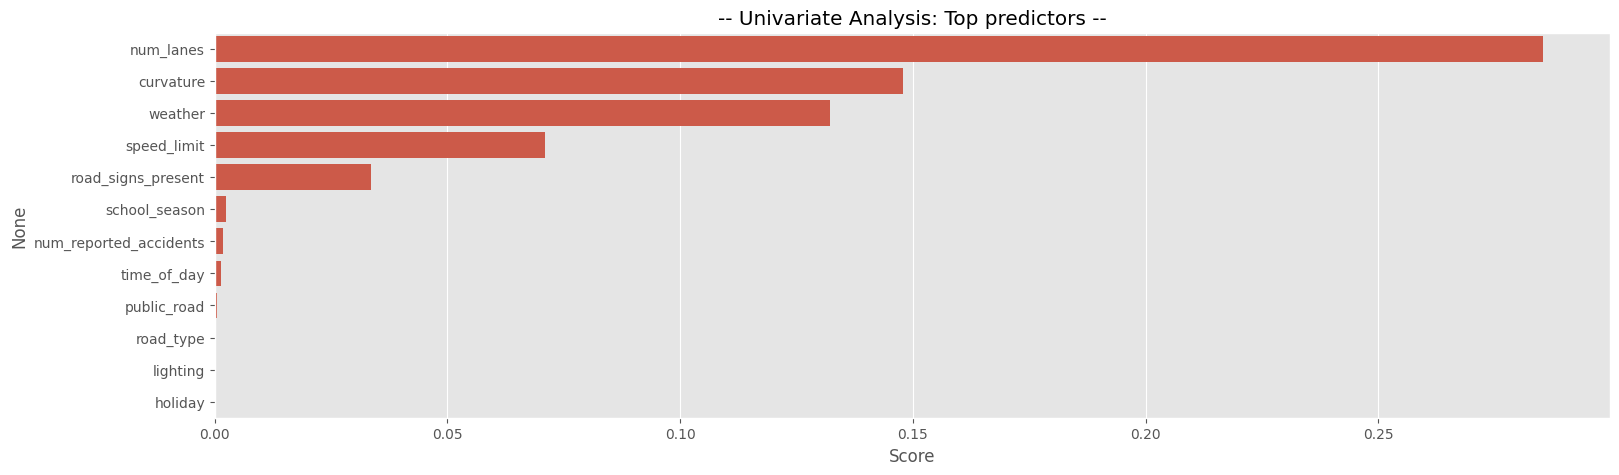

CPU times: user 1min 31s, sys: 180 ms, total: 1min 31s
Wall time: 1min 31s


In [26]:
%%time
## -- Mutual Info: Features vs Target --
mutual_info = mutual_info_regression(train[FEATURES], train[TARGET])
mutual_info_df = pd.DataFrame.from_dict(
                        dict(zip(test.columns.tolist(),
                        list(mutual_info))),
                        orient='index', columns=['Score'],
).sort_values(by='Score', ascending=False)

plt.figure(figsize=(18, 5))
sns.barplot(data=mutual_info_df, x='Score', y=mutual_info_df.index)
plt.title("-- Univariate Analysis: Top predictors --")
plt.show()

### PROFILE REPORT

In [27]:
# %%capture
# ## -- Comprehensive EDA --
# !{sys.executable} -m pip install -U ydata-profiling[notebook]
# !pip install jupyter-contrib-nbextensions
# !jupyter nbextension enable --py widgetsnbextension

# from ydata_profiling import ProfileReport, compare

# ## -- Single EDA --
# profile_df = ProfileReport(train, title="Insights into y Types", explorative=True)
# profile_df.to_notebook_iframe()

# profile_df.to_file("Beats_EDA_Report.html")

# ## -- Create Profiles for Datasets --
# train_report = ProfileReport(train, title="Train", explorative=True)
# test_report = ProfileReport(test, title="Test", explorative=True)
# orig_report = ProfileReport(orig, title="Original", explorative=True)

# ## -- Compare 2++ Datasets --
# comparison_report = compare([train_report, orig_report])

# ## -- Obtain merged statistics (Don't know its purpose yet)
# statistics = comparison_report.get_description()
# ## -- Save report to file
# comparison_report.to_file("Accidents_Train-Orig_Stats.html")
# comparison_report.to_notebook_iframe()

# ML TRAINING

In [28]:
# train = pd.concat([train, orig], ignore_index=True)
# train.name = 'original_as_rows'

print(f"Merging {len(FEATURES)} features...", end="")
for c in FEATURES:
    tmp = orig.groupby(c)[TARGET].mean()
    n = f"orig_{c}"
    print(f"{n}, ", end="")
    tmp.name = n
    train = train.merge(tmp, on=c, how='left')
    test  = test.merge(tmp, on=c, how='left')
    train.name = 'original_as_columns'

train.head()

Merging 12 features...orig_num_lanes, orig_curvature, orig_speed_limit, orig_num_reported_accidents, orig_road_type, orig_lighting, orig_weather, orig_road_signs_present, orig_public_road, orig_time_of_day, orig_holiday, orig_school_season, 

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk,orig_num_lanes,orig_curvature,orig_speed_limit,orig_num_reported_accidents,orig_road_type,orig_lighting,orig_weather,orig_road_signs_present,orig_public_road,orig_time_of_day,orig_holiday,orig_school_season
0,0,2,0.06,35,0,0,0,0,0,0,0,1,0.13,0.383454,0.257733,0.302750,0.362937,0.383942,0.317262,0.417100,0.383140,0.382403,0.383335,0.383260,0.382813
1,0,4,0.99,35,0,1,1,1,1,1,0,0,0.35,0.383503,0.524877,0.302750,0.364480,0.383942,0.317262,0.316538,0.382812,0.383545,0.383720,0.382695,0.382813
2,1,4,0.63,70,1,1,0,0,2,1,1,2,0.30,0.383503,0.426885,0.503229,0.363730,0.382619,0.316692,0.316538,0.383140,0.382403,0.381874,0.382695,0.383138
3,2,4,0.07,35,1,0,1,0,2,0,1,1,0.21,0.383503,0.244335,0.302750,0.362937,0.382364,0.316692,0.417100,0.382812,0.382403,0.381874,0.383260,0.383138
4,1,1,0.58,60,0,2,0,1,1,1,1,1,0.56,0.381967,0.409345,0.502197,0.362937,0.382619,0.317262,0.415970,0.383140,0.383545,0.383720,0.382695,0.383138


In [29]:
test.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,orig_num_lanes,orig_curvature,orig_speed_limit,orig_num_reported_accidents,orig_road_type,orig_lighting,orig_weather,orig_road_signs_present,orig_public_road,orig_time_of_day,orig_holiday,orig_school_season
0,2,2,0.34,45,2,1,1,0,0,1,0,1,0.383454,0.341785,0.302929,0.362937,0.382364,0.514757,0.316538,0.382812,0.382403,0.383335,0.382695,0.382813
1,0,3,0.04,45,1,2,1,1,0,1,1,0,0.382990,0.244524,0.302929,0.364480,0.383942,0.316692,0.415970,0.382812,0.383545,0.383335,0.382695,0.383138
2,0,2,0.59,35,1,1,1,1,0,1,0,1,0.383454,0.414431,0.302750,0.362937,0.383942,0.316692,0.316538,0.382812,0.383545,0.383335,0.382695,0.382813
3,1,4,0.95,35,0,0,0,1,0,0,1,2,0.383503,0.518590,0.302750,0.363730,0.382619,0.317262,0.417100,0.383140,0.383545,0.383335,0.383260,0.383138
4,2,2,0.86,35,0,1,1,1,1,0,0,3,0.383454,0.479198,0.302750,0.465450,0.382364,0.317262,0.316538,0.382812,0.383545,0.383720,0.383260,0.382813


In [30]:
## -- Define Models --
models = {
    'XGB': xgb.XGBRegressor(eval_metric='rmse', random_state=SEED, n_jobs=-1, verbosity=0),
    'LGB': lgb.LGBMRegressor(metric='rmse', random_state=SEED, n_jobs=-1, verbose=-1),
    'CAT': cgb.CatBoostRegressor(eval_metric='RMSE', random_state=SEED, verbose=0,
                                 allow_writing_files=False, thread_count=-1),
}

print(f"Models to train: {len(models)}", end=" --> ")
print(list(models.keys()))

Models to train: 3 --> ['XGB', 'LGB', 'CAT']


ℹ️ INFO: Training with original_as_columns


Training:   0%|          | 0/3 [00:00<?, ?it/s]


[1] XGB ████████████████████████████████████████
	Fold 1/5 RMSE: 0.056294
	Fold 2/5 RMSE: 0.056181
	Fold 3/5 RMSE: 0.056229
	Fold 4/5 RMSE: 0.056031
	Fold 5/5 RMSE: 0.055972
|----------------------------------------------------
|  Overall OOF RMSE: 0.056141
| Average Fold RMSE: 0.056141 ± 0.000121


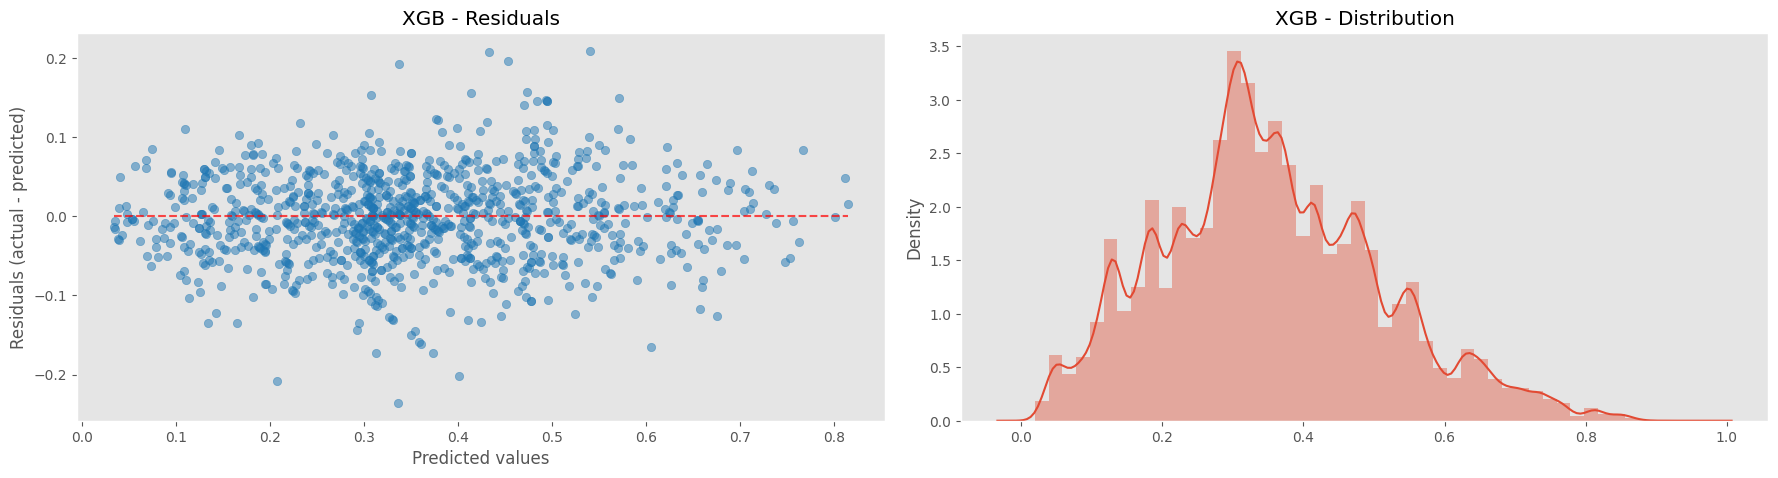

Duration: 25.63 secs ####################

[2] LGB ████████████████████████████████████████
	Fold 1/5 RMSE: 0.056330
	Fold 2/5 RMSE: 0.056188
	Fold 3/5 RMSE: 0.056212
	Fold 4/5 RMSE: 0.056094
	Fold 5/5 RMSE: 0.056022
|----------------------------------------------------
|  Overall OOF RMSE: 0.056169
| Average Fold RMSE: 0.056169 ± 0.000105


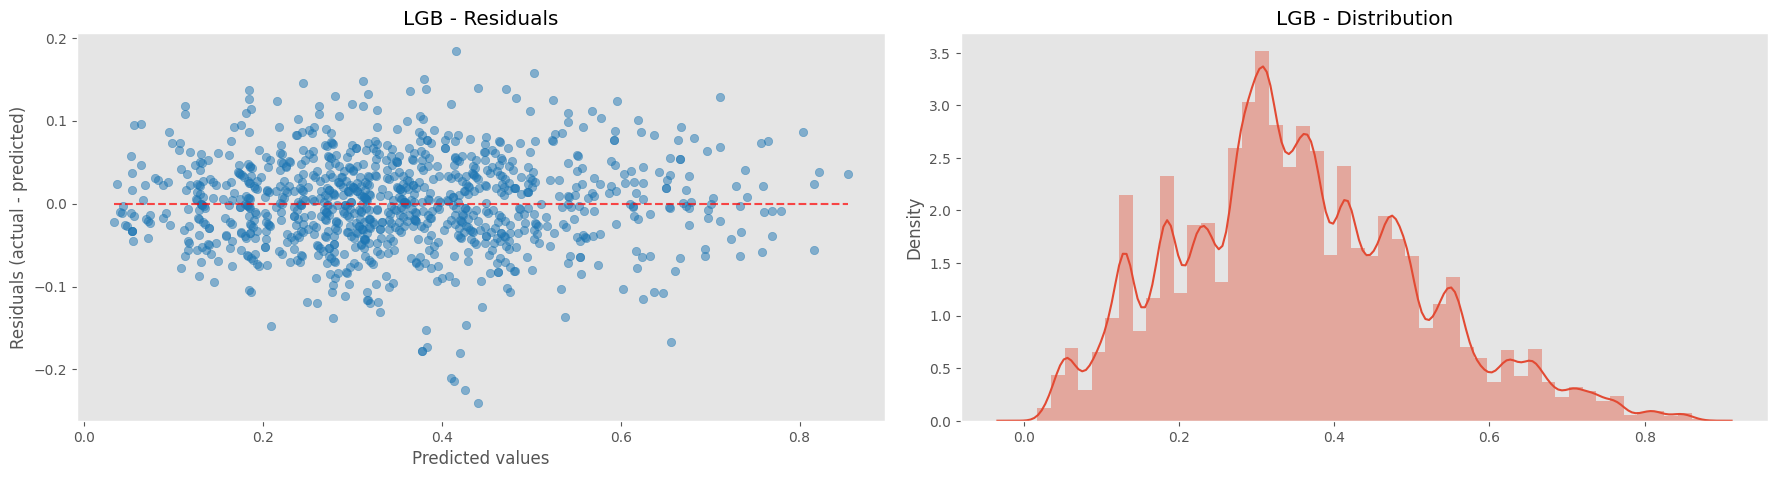

Duration: 22.84 secs ####################

[3] CAT ████████████████████████████████████████
	Fold 1/5 RMSE: 0.056221
	Fold 2/5 RMSE: 0.056068
	Fold 3/5 RMSE: 0.056155
	Fold 4/5 RMSE: 0.055996
	Fold 5/5 RMSE: 0.055899
|----------------------------------------------------
|  Overall OOF RMSE: 0.056068
| Average Fold RMSE: 0.056068 ± 0.000114


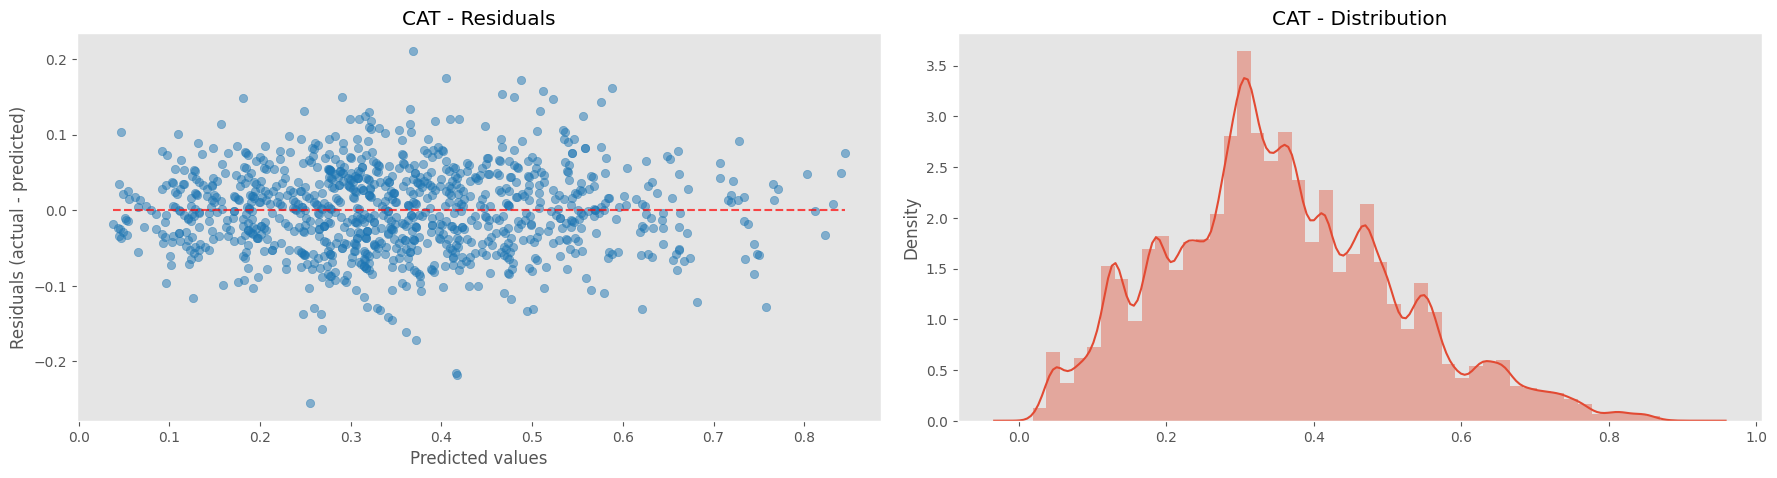

Duration: 187.65 secs ####################


In [31]:
## -- DEFINE TRAINING PARAMETERS --
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

## -- Split data --
X = train.drop(columns=[TARGET])
y = train[TARGET]

oof_final_df  = pd.DataFrame()
test_final_df = pd.DataFrame()

all_models = {}
FOLDS      = 5

kf = KFold(n_splits=FOLDS, shuffle=True, random_state=SEED)

## -- Initiate Training -- ##
print(f"ℹ️ INFO: Training with {train.name}")
## -----------------------------------------------------------------------
for i, (name, model) in tqdm(enumerate(models.items(), 1), total=len(models), desc="Training"):
    print(f"\n[{i}] {COLOR}{name} {'█'*40}{RESET}")
    tik = time()

    oof_preds  = np.zeros(len(X))
    test_preds = np.zeros(len(test))
    fold_RMSEs = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
            
        model.fit(X_train_fold, y_train_fold)

        oof_preds[val_idx] = np.clip(model.predict(X_val_fold), 0, 1)
        fold_rmse = rmse(y_val_fold, np.clip(model.predict(X_val_fold), 0, 1))
        fold_RMSEs.append(fold_rmse)

        predictions = model.predict(test)
        test_preds += np.clip(predictions, 0, 1) / FOLDS


        print(f"\tFold {fold}/{FOLDS} RMSE: {fold_rmse:.6f}")

    ## -- After all folds --
    overall_RMSE = rmse(y, oof_preds)
    print(f"|{'-'*52}")
    print(f"{COLOR}|  Overall OOF RMSE: {overall_RMSE:.6f}")
    print(f"| Average Fold RMSE: {np.mean(fold_RMSEs):.6f} ± {np.std(fold_RMSEs):.6f}{RESET}")
    ## -- Plot ROC CURVE --
    fig, axs = plt.subplots(1, 2, figsize=(18, 5))
    display = PredictionErrorDisplay.from_predictions(
                        y, oof_preds, ax=axs[0],
                        # kind="actual_vs_predicted",
                        subsample=1000,
                        scatter_kwargs={"alpha": 0.5},
                        line_kwargs={'color': 'r'},
                    )
    axs[0].set_title(f"{name} - Residuals")
    # -----------------------------------------------------
    sns.distplot(oof_preds, ax=axs[1])
    axs[1].set_title(f"{name} - Distribution") 
    # -----------------------------------------------------
    for ax in axs: ax.grid(False)
    fig.tight_layout(pad=1.5) 
    plt.show()

    oof_final_df[name]  = oof_preds
    test_final_df[name] = test_preds
    all_models[name]    = model

    tok = time()
    tiktok = tok-tik
    print(f"Duration: {tiktok:.2f} secs {'#'*20}")

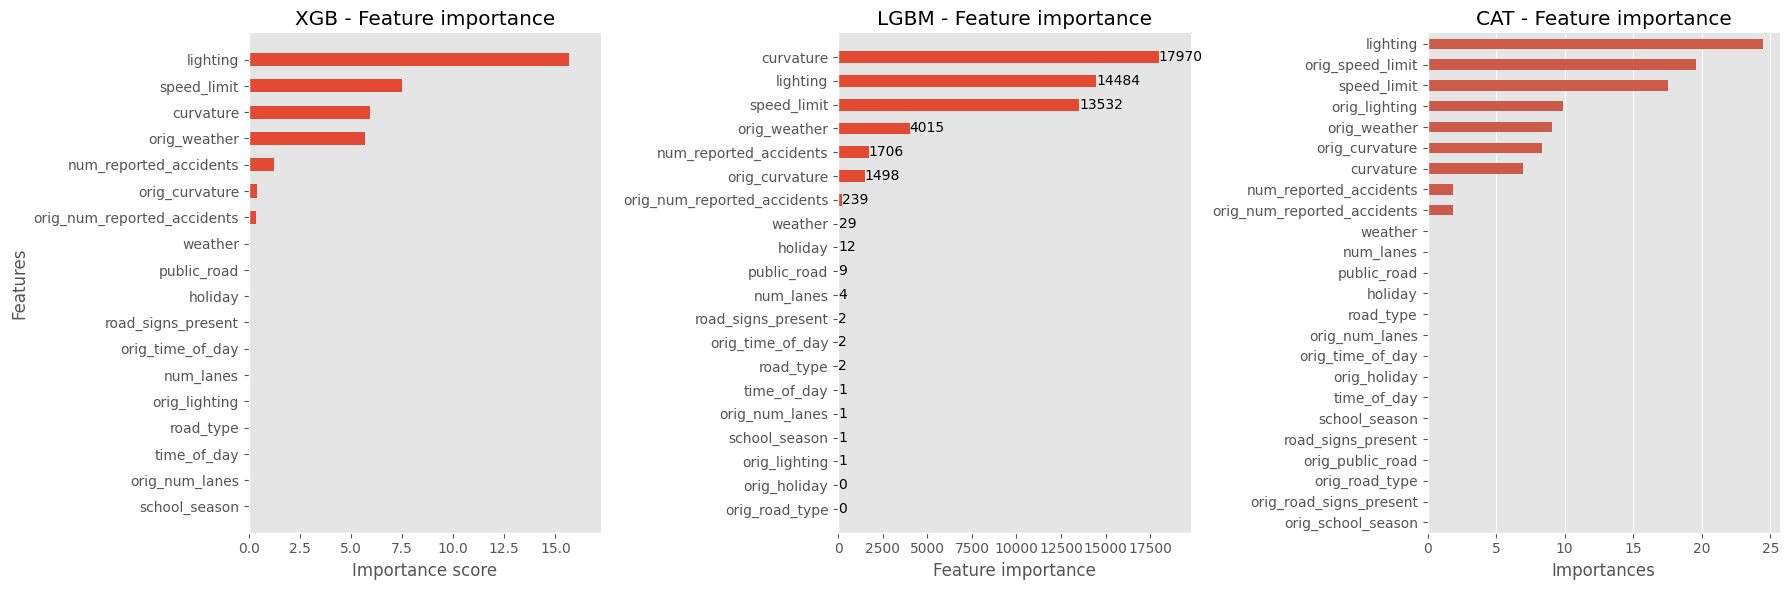

In [32]:
## -- PLOT FEATURES IMPORTANCES -- 
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

## -- XGBoost -- 
xgb.plot_importance(all_models['XGB'], importance_type='gain',
                    ax=axs[0], grid=False, height=.5, show_values=False,
                    title="XGB - Feature importance")

## -- LightGBM -- 
lgb.plot_importance(all_models['LGB'], importance_type='gain',
                    ax=axs[1], grid=False, height=.5, precision=0,
                    title="LGBM - Feature importance")
axs[1].set_ylabel("")

## -- CatBoost -- 
cat_imp_df = all_models['CAT'].get_feature_importance(prettified=True)
sns.barplot(data=cat_imp_df, x='Importances', y='Feature Id', width=.5, ax=axs[2])
axs[2].set_title('CAT - Feature importance')
axs[2].set_ylabel("")

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

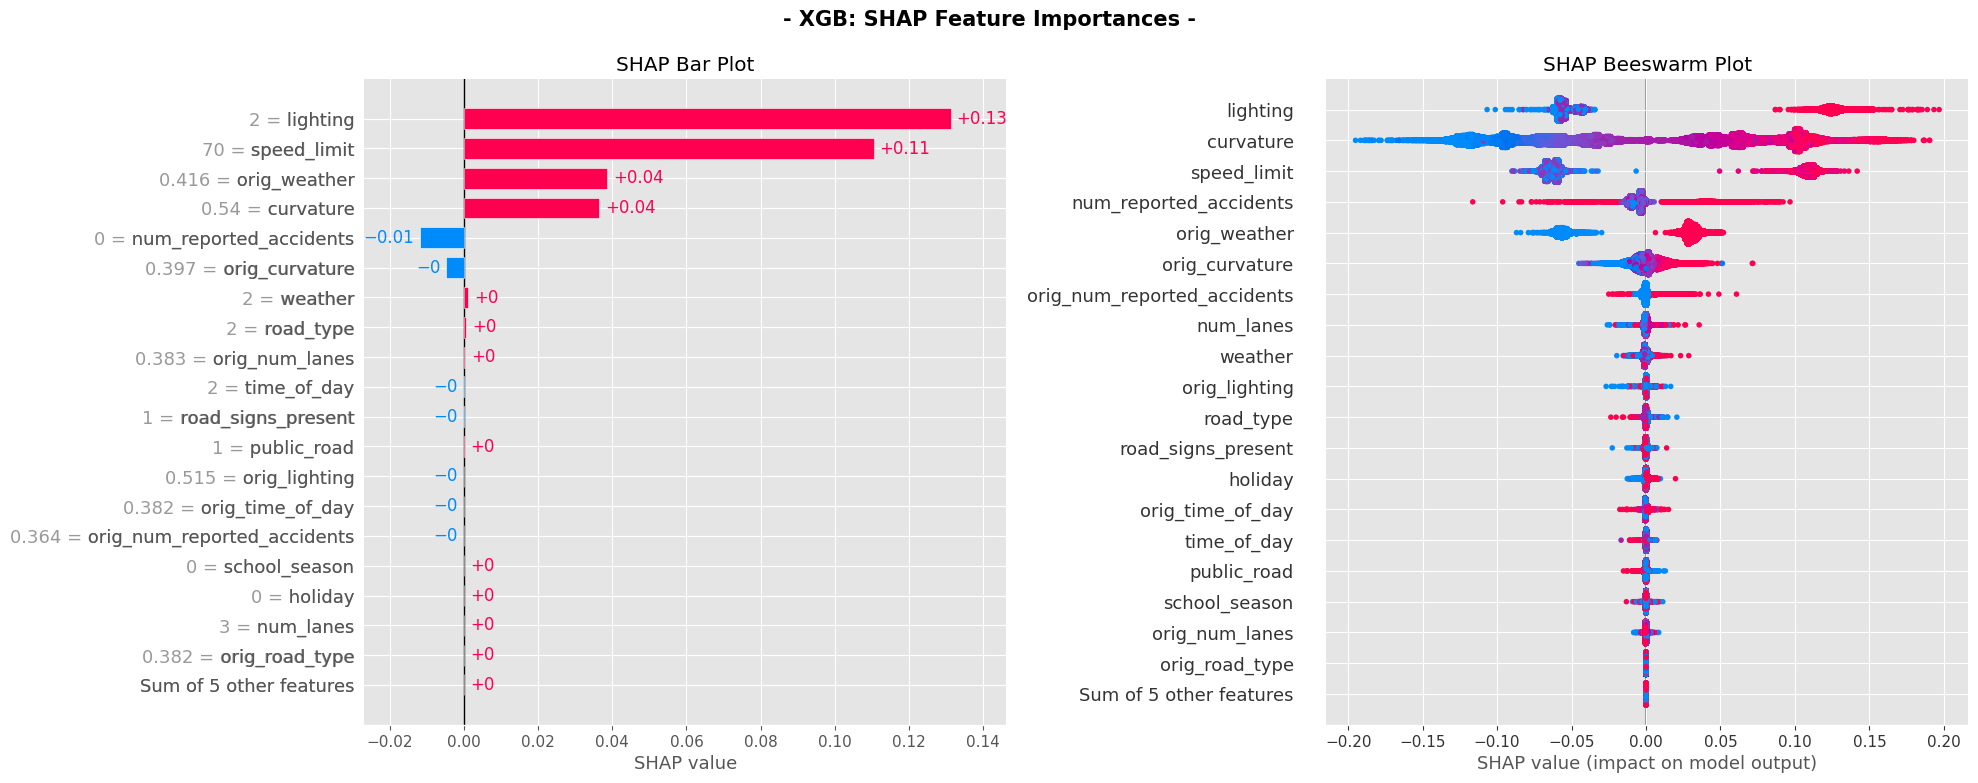

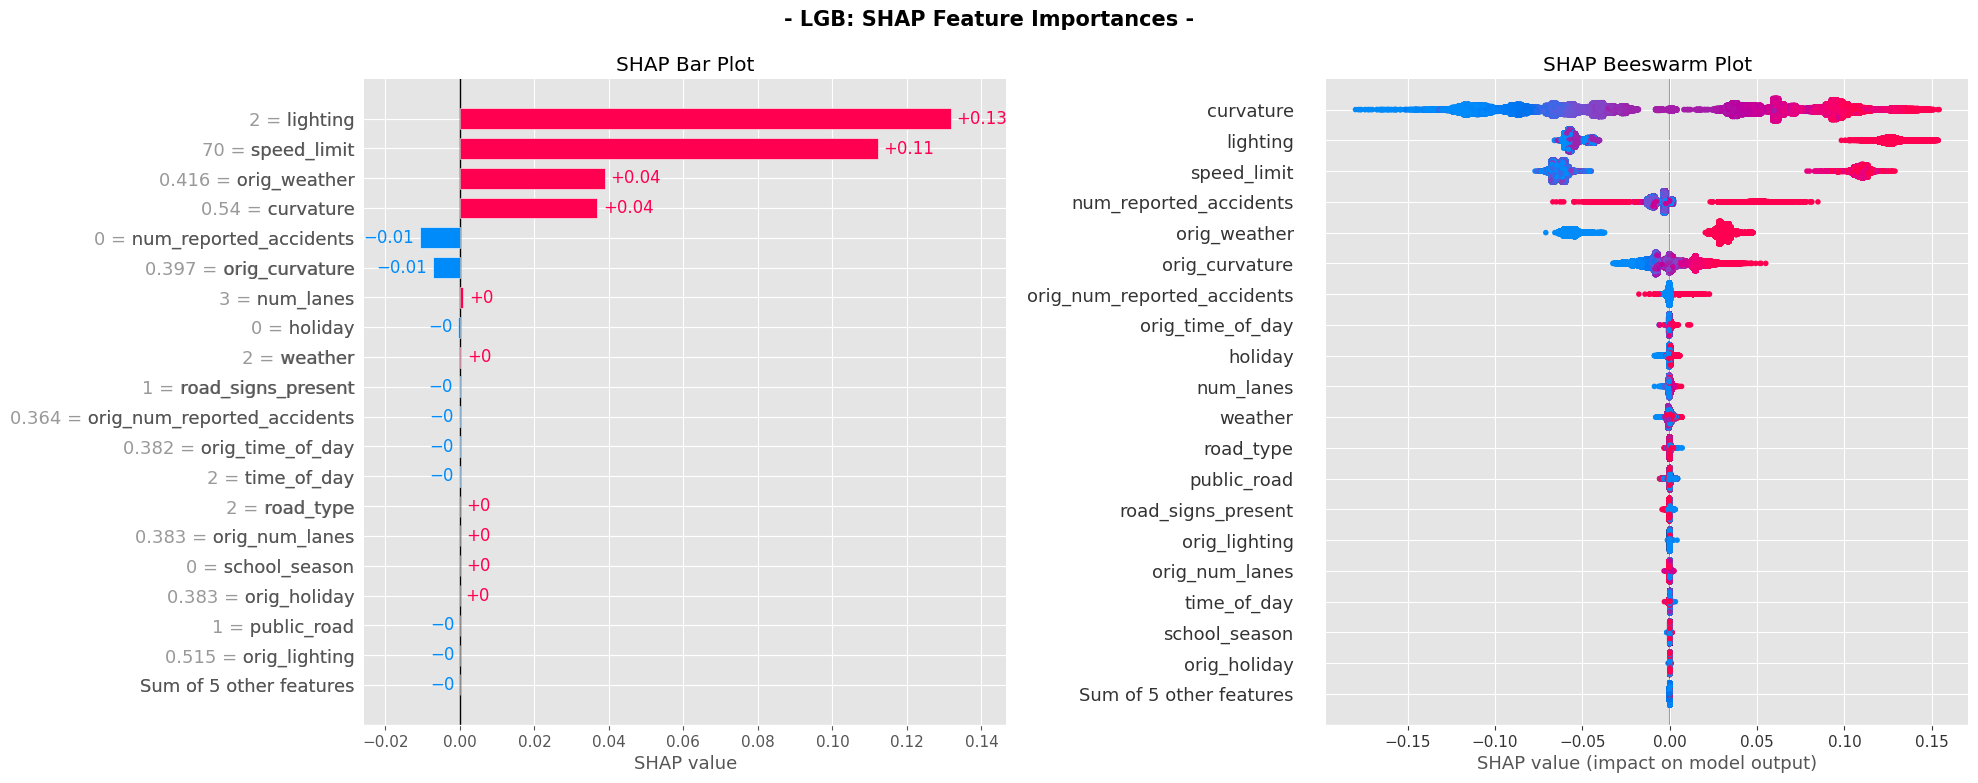

In [33]:
## -- Plot SHAP values --
MAX = 20
for i, (name, model) in enumerate(all_models.items()):
    if name in ['XGB', 'LGB']: # -> plot only xgboost & lightgbm
        fig, axs = plt.subplots(1, 2, figsize=(20, 8))
        # Shap Explainer
        explainer = shap.TreeExplainer(model)
        explanation = explainer(X_val_fold)
        # Bar plot 
        shap.plots.bar(explanation[0], max_display=MAX, ax=axs[0], show=False)
        axs[0].set_title("SHAP Bar Plot")
        # Beeswarm plot
        shap.plots.beeswarm(explanation, max_display=MAX, ax=axs[1], show=False,
                            order=explanation.abs.max(0), # <-most impactful feature
                            color_bar=False, plot_size=None,)
        axs[1].set_title("SHAP Beeswarm Plot") 
        fig.suptitle(f"- {name}: SHAP Feature Importances -", fontsize=15, fontweight='semibold')
        fig.tight_layout(pad=1.5) 
        plt.show()
        print()

In [34]:
## -- Predictions/OOF of models --
test_final_df.head(), oof_final_df.head()

(        XGB       LGB       CAT
 0  0.294677  0.293073  0.292660
 1  0.121580  0.127148  0.120659
 2  0.185195  0.185970  0.186459
 3  0.312649  0.322920  0.311813
 4  0.400505  0.415785  0.392324,
         XGB       LGB       CAT
 0  0.127362  0.129390  0.127535
 1  0.321698  0.323931  0.320143
 2  0.388293  0.388907  0.387693
 3  0.128428  0.131474  0.127380
 4  0.470791  0.473484  0.471000)

In [35]:
## -- Create Submissions for each model --
for c in test_final_df.columns:
    submit[TARGET] = test_final_df[c].values
    submit.to_csv(f"submit_{c}_base.csv", index=False)
    print(f"{COLOR}-> submit_{c}_base.csv file saved!")

-> submit_XGB_base.csv file saved!
-> submit_LGB_base.csv file saved!
-> submit_CAT_base.csv file saved!
